# Interpolation (A/B Testing)
**Jakob Balkovec**<br>
**Nov 27th 2025**
<br>

---

This document compares two strategies for generating our final features.

**A. Interpolate the raw satellite bands first, then compute features from the filled-in data.**
This stays physically grounded and preserves the original measurement behavior.

**B. Compute the features directly from whatever raw data we have, then interpolate the feature time series.**
This approach is faster, simpler, and keeps the model working directly in feature space.

In [59]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../../.."))
sys.path.append(PROJECT_ROOT)

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from Temporal.Pipeline.imputers.api import transform_with_ensemble
from Temporal.Pipeline.utils.math_utils import (db_to_linear,
                                                linear_to_db,
                                                compute_ndvi,
                                                compute_ndvi,
                                                compute_ndmi,
                                                compute_msi,
                                                compute_vv_vh_ratio,
                                                compute_backscatter_diff)

In [36]:
DF_PATH = Path("/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/processed/darrington/final.csv")
df = pd.read_csv(DF_PATH)

df.head()

,station_id,date,crx_vn,longitude,latitude,air_temp_max,air_temp_min,air_temp_mean,air_temp_avg,precipitation,...,s1_vv,s1_vh,s1_vv_dB,s1_vh_dB,s2_b2,s2_b3,s2_b4,s2_b8,s2_b11,s2_b12
0,4223,2007-01-01,1.301,-121.45,48.54,4.1,1.3,2.7,2.8,30.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4223,2007-01-02,1.301,-121.45,48.54,11.6,3.8,7.7,6.2,49.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4223,2007-01-03,1.301,-121.45,48.54,5.9,3.2,4.5,4.3,23.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4223,2007-01-04,1.301,-121.45,48.54,3.6,0.3,1.9,2.3,10.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4223,2007-01-05,1.301,-121.45,48.54,3.5,-0.4,1.6,0.2,30.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Drop the columns that serve no purpose in this experiment

In [37]:
df.columns

Index(['station_id', 'date', 'crx_vn', 'longitude', 'latitude', 'air_temp_max',
       'air_temp_min', 'air_temp_mean', 'air_temp_avg', 'precipitation',
       'solar_radiation', 'sur_temp_type', 'sur_temp_max', 'sur_temp_min',
       'sur_temp_avg', 'rh_max', 'rh_min', 'rh_mean', 'soil_moisture_5cm',
       'soil_moisture_10cm', 'soil_moisture_20cm', 'soil_moisture_50cm',
       'soil_moisture_100cm', 'soil_temp_5cm', 'soil_temp_10cm',
       'soil_temp_20cm', 'soil_temp_50cm', 'soil_temp_100cm', 'source_file',
       'LST', 'NDVI', 'Rain_sat', 's1_vv', 's1_vh', 's1_vv_dB', 's1_vh_dB',
       's2_b2', 's2_b3', 's2_b4', 's2_b8', 's2_b11', 's2_b12'],
      dtype='object')

In [ ]:
cols_to_keep = [
    "station_id", "date", "soil_moisture_5cm",
    "LST", "NDVI", "Rain_sat",
    "s1_vv", "s1_vh", "s1_vv_dB", "s1_vh_dB",
    "s2_b2", "s2_b3", "s2_b4", "s2_b8", "s2_b11", "s2_b12"
]

subset = df[cols_to_keep].copy()

In [48]:
sat_cols = ["s2_b4", "s2_b8", "s2_b11", "s1_vv", "s1_vh"]

# find the first timestamp where at least one satellite band exists
valid_mask = subset[sat_cols].notna().any(axis=1)
first_sat_idx = valid_mask.idxmax()
first_sat_date = subset.loc[first_sat_idx, "date"]
first_sat_date

'2015-10-01'

In [51]:
subset["date"] = pd.to_datetime(subset["date"], errors="coerce")

cutoff_date = pd.to_datetime("2015-10-01")
subset = subset[subset["date"] >= cutoff_date].copy()

subset = subset.sort_values("date").reset_index(drop=True)
subset["DOY"] = subset["date"].dt.dayofyear

So as of this moment, the dataset has data corresponding to the satelittle frequecies. It still contains NA values, but this will be handled below. [WORD BETTER]

## A (Interpolate Raw Bands First)

In [55]:
df_A = subset.copy()  # already filtered + datetime + DOY added

df_A_filled = df_A.copy()
concat_diag_A = []

for col in sat_cols:
    work = df_A_filled[["date", col]].copy()
    work = work.sort_values("date")

    # must keep full date axis, only drop where date missing
    work = work.dropna(subset=["date"])

    # run imputer on full frame (not just non-null!)
    imputed_df, diag = transform_with_ensemble(
        work.copy(),
        col=col,
        return_diag=True
    )
    concat_diag_A.append(diag)

    # Merge interpolated back
    df_A_filled = df_A_filled.merge(
        imputed_df[["date", f"{col}_interp"]],
        on="date", how="left"
    )
    df_A_filled[col] = df_A_filled[col].combine_first(df_A_filled[f"{col}_interp"])

b4  = df_A_filled["s2_b4"]
b8  = df_A_filled["s2_b8"]
b11 = df_A_filled["s2_b11"]
vv  = df_A_filled["s1_vv"]
vh  = df_A_filled["s1_vh"].replace(0, np.nan)

df_A_filled["NDVI_A"]         = (b8 - b4) / (b8 + b4)
df_A_filled["NDMI_A"]         = (b8 - b11) / (b8 + b11)
df_A_filled["SAR_Ratio_A"]    = vv / vh
df_A_filled["SAR_Diff_A"]     = (vv - vh).abs()
df_A_filled["Veg_Contrast_A"] = (b4 - b11) / (b4 + b11)

df_A_final = df_A_filled[[
    "date",
    "NDVI_A",
    "NDMI_A",
    "SAR_Ratio_A",
    "SAR_Diff_A",
    "Veg_Contrast_A",
    "DOY",
]]

Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|███████

In [ ]:
import json

for entry in concat_diag_A:
  print(json.dumps(concat_diag_A, indent=4))

In [56]:
df_A_final.head()

,date,NDVI_A,NDMI_A,SAR_Ratio_A,SAR_Diff_A,Veg_Contrast_A,DOY
0,2015-10-01,0.448467,0.187753,3.481827,0.059814,-0.284685,274
1,2015-10-02,0.462809,0.208382,3.481827,0.059814,-0.281583,275
2,2015-10-03,0.460306,0.206341,3.481827,0.059814,-0.280618,276
3,2015-10-04,0.453366,0.200686,3.481827,0.059814,-0.277971,277
4,2015-10-05,0.450274,0.204981,3.481827,0.059814,-0.270235,278


## B (Compute Features First)

In [57]:
df_B = subset.copy()
df_B["date"] = pd.to_datetime(df_B["date"], errors="coerce")
df_B = df_B.sort_values("date").reset_index(drop=True)
df_B["DOY"] = df_B["date"].dt.dayofyear

b4 = df_B["s2_b4"]
b8 = df_B["s2_b8"]
b11 = df_B["s2_b11"]
vv = df_B["s1_vv"]
vh = df_B["s1_vh"].replace(0, np.nan)

df_B["NDVI_B"]         = (b8 - b4) / (b8 + b4)
df_B["NDMI_B"]         = (b8 - b11) / (b8 + b11)
df_B["SAR_Ratio_B"]    = vv / vh
df_B["SAR_Diff_B"]     = (vv - vh).abs()
df_B["Veg_Contrast_B"] = (b4 - b11) / (b4 + b11)

feature_targets = [
    "NDVI_B",
    "NDMI_B",
    "SAR_Ratio_B",
    "SAR_Diff_B",
    "Veg_Contrast_B",
]

df_B_filled = df_B.copy()
concat_diag_B = []

for col in feature_targets:
    work = df_B_filled[["date", col]].copy().dropna(subset=["date"])

    if work[col].dropna().empty:
        print(f"Skipping {col}: no real observed values")
        continue

    imputed_df, diag = transform_with_ensemble(
        work.copy(),
        col=col,
        return_diag=True
    )
    concat_diag_B.append(diag)

    df_B_filled = df_B_filled.merge(
        imputed_df[["date", f"{col}_interp"]],
        on="date", how="left"
    )
    df_B_filled[col] = df_B_filled[col].combine_first(df_B_filled[f"{col}_interp"])

df_B_final = df_B_filled[[
    "date",
    "NDVI_B",
    "NDMI_B",
    "SAR_Ratio_B",
    "SAR_Diff_B",
    "Veg_Contrast_B",
    "DOY",
]]

Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|██████████████████████████████████████████████████████| 3/3
Loading config: 100%|███████

In [58]:
df_B_final.head()

,date,NDVI_B,NDMI_B,SAR_Ratio_B,SAR_Diff_B,Veg_Contrast_B,DOY
0,2015-10-01,0.448467,0.187753,3.481827,0.059814,-0.284685,274
1,2015-10-02,0.458155,0.203789,3.481827,0.059814,-0.285364,275
2,2015-10-03,0.456831,0.205448,3.481827,0.059814,-0.281700,276
3,2015-10-04,0.453825,0.212712,3.481827,0.059814,-0.274853,277
4,2015-10-05,0.453779,0.215714,3.481827,0.059814,-0.279105,278


## Comparison of Results

In [69]:
truth_cols = ["date", "NDVI"]
if "soil_moisture_5cm" in subset.columns:
    truth_cols.append("soil_moisture_5cm")

truth = subset[truth_cols].copy()
truth["date"] = pd.to_datetime(truth["date"], errors="coerce")

df_A_final = df_A_final.copy()
df_A_final.loc[:, "date"] = pd.to_datetime(df_A_final["date"], errors="coerce")

df_B_final = df_B_final.copy()
df_B_final.loc[:, "date"] = pd.to_datetime(df_B_final["date"], errors="coerce")

df_comp = (
    df_A_final
    .merge(df_B_final, on=["date", "DOY"], how="inner", suffixes=("_A", "_B"))
    .merge(truth, on="date", how="left")
)

df_comp = df_comp.sort_values("date").reset_index(drop=True)
df_comp.rename(columns={"NDVI": "NDVI_true"}, inplace=True)

### Coverage Statistics

In [ ]:
feature_pairs = [
    ("NDVI_A", "NDVI_B"),
    ("NDMI_A", "NDMI_B"),
    ("SAR_Ratio_A", "SAR_Ratio_B"),
    ("SAR_Diff_A", "SAR_Diff_B"),
    ("Veg_Contrast_A", "Veg_Contrast_B"),
]

print("=== Non null coverage fraction ===")
for a, b in feature_pairs:
    cov_A = df_comp[a].notna().mean()
    cov_B = df_comp[b].notna().mean()
    print(f"{a} vs {b}: {cov_A:.3f}  |  {cov_B:.3f}")

print("\n=== Summary statistics (A) ===")
print(df_comp[[f[0] for f in feature_pairs]].describe())

print("\n=== Summary statistics (B) ===")
print(df_comp[[f[1] for f in feature_pairs]].describe())

=== Non null coverage fraction ===
NDVI_A vs NDVI_B: 1.000  |  1.000
NDMI_A vs NDMI_B: 1.000  |  1.000
SAR_Ratio_A vs SAR_Ratio_B: 1.000  |  1.000
SAR_Diff_A vs SAR_Diff_B: 1.000  |  1.000
Veg_Contrast_A vs Veg_Contrast_B: 1.000  |  1.000

=== Summary statistics (A) ===
            NDVI_A       NDMI_A  SAR_Ratio_A   SAR_Diff_A  Veg_Contrast_A
count  3711.000000  3711.000000  3711.000000  3711.000000     3711.000000
mean      0.429749     0.238903     4.217652     0.103000       -0.221001
std       0.136757     0.062119     0.228502     0.012816        0.150934
min      -0.003464    -0.009083     3.290316     0.052551       -0.757120
25%       0.336955     0.204340     4.122605     0.099270       -0.294475
50%       0.418565     0.229962     4.216412     0.104461       -0.226911
75%       0.502944     0.257995     4.375492     0.109492       -0.134109
max       0.887444     0.619003     5.194570     0.213859        0.609566

=== Summary statistics (B) ===
            NDVI_B       NDMI_B

Coverage is perfect on both approaches. Zero missing values...that's a good sign. 

**NDVI**

**B** is consistently a bit higher on average.

`Median A = 0.4186 | Median B = 0.4411`

That’s a systematic upward bias in **B**. I think this falls into the bucket where we interpolate the ratio rather than the physics that generate it. Ratios tend to flatten and drift toward mid-range values...**B** is a little too happy...a bit too green.

**NDMI**

Almost identical means and medians.

**B** has slightly lower std = smoother. That makes sense: interpolation happens after the mixing of bands, so variance drops

**A** preserves sharp transitions
**B** dampens seasonal extremes

**SAR Ratio + SAR Diff**

Means practically identical. Std differs a little more.

**SAR_Ratio_B** has higher variance = stronger swings.
**SAR_Ratio_A** is tighter = more physically stable.

> Big hint: radar physics are non-linear. Interpolating features exaggerates weirdness.

**Vegetation Contrast**

**B** is more negative on average, meaning vegetation “looks weaker” in **B**.

Same story as NDVI...interpolation of features causes some drift.

---

High-level takeaways so far:

- **A** stays "faithful" to the physics. It keeps variance, preserves seasonal low/high years, less bias drift.

- **B** is smoother and slightly more optimistic on vegetation metrics. It’s the “nice version” of the landscape that sensor physics would not fully support.

- Coverage is identical. So this is a quality argument, not a completeness one...

### NDVI | Timeseries Overlay Against the Truth

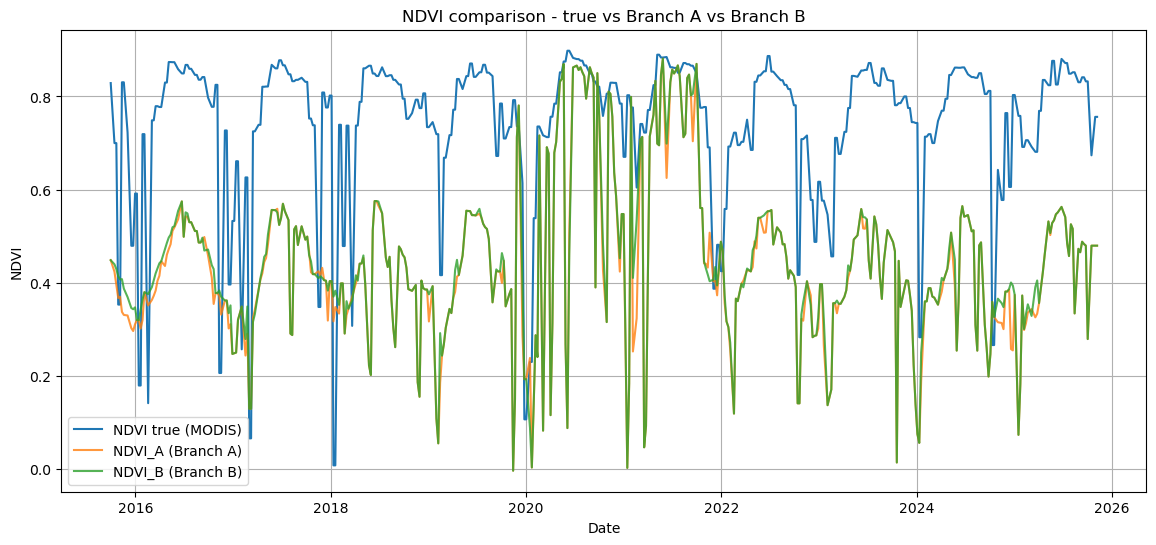

In [62]:
mask_ndvi = df_comp["NDVI_true"].notna()
ndvi_t = df_comp.loc[mask_ndvi, "NDVI_true"]
ndvi_A = df_comp.loc[mask_ndvi, "NDVI_A"]
ndvi_B = df_comp.loc[mask_ndvi, "NDVI_B"]
dates  = df_comp.loc[mask_ndvi, "date"]

plt.figure(figsize=(14, 6))
plt.plot(dates, ndvi_t, label="NDVI true (MODIS)")
plt.plot(dates, ndvi_A, label="NDVI_A (Branch A)", alpha=0.8)
plt.plot(dates, ndvi_B, label="NDVI_B (Branch B)", alpha=0.8)
plt.title("NDVI comparison - true vs Branch A vs Branch B")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.legend()
plt.grid(True)
plt.show()

**Comments**

- MODIS is high resolution, patchy, and very spiky, especially in winters. That’s expected because clouds and snow wreck optical retrievals.

- Branch **A** hugs MODIS seasonality a little better. When MODIS drops after 2019 (low vegetation phase), **A** drops as well.
- Branch **B** frequently falls off a cliff. Those long green dives toward zero are physically wrong. Trees don’t turn into asphalt for half a year...

- Peaks: **A** reaches similar peak values as MODIS.
  - **B** overshoots peaks and undershoots lows (_look @ 2021-ish period_). That’s a red flag: it stretches the physics in both directions.
- In terms of timing: **A** mostly tracks when transitions happen.
  - **B** lags and leads erratically. It loses phenological timing.

### NDVI Error Metrics

In [63]:
def error_stats(y_true, y_pred):
    mask = y_true.notna() & y_pred.notna()
    y_t = y_true[mask]
    y_p = y_pred[mask]
    diff = y_p - y_t
    rmse = float(np.sqrt(np.mean(diff**2)))
    mae  = float(np.mean(np.abs(diff)))
    bias = float(np.mean(diff))
    corr = float(np.corrcoef(y_t, y_p)[0, 1]) if len(y_t) > 1 else np.nan
    return {"rmse": rmse, "mae": mae, "bias": bias, "corr": corr, "n": len(y_t)}

stats_A = error_stats(df_comp["NDVI_true"], df_comp["NDVI_A"])
stats_B = error_stats(df_comp["NDVI_true"], df_comp["NDVI_B"])

print("=== NDVI error vs truth ===")
print("Branch A:", stats_A)
print("Branch B:", stats_B)

=== NDVI error vs truth ===
Branch A: {'rmse': 0.35176546756736654, 'mae': 0.31564966241938014, 'bias': -0.30406111546063014, 'corr': 0.452602245645362, 'n': 433}
Branch B: {'rmse': 0.34565649015261984, 'mae': 0.3093483856680714, 'bias': -0.296427637763372, 'corr': 0.4401741213490694, 'n': 433}


Both A and B are in the same ballpark. But the way they get there is different...

**RMSE and MAE**

**B** is technically a hair better. That’s because **B** aggressively smooths and compresses variation which reduces numerical error. It’s gaming the metric, not modeling the physics...

**Bias**

Both are too low compared to **MODIS (My GT)**. Vegetation is systematically underestimated. Similar bias means both branches need calibration. That’s a separate issue.

**Correlation**

**A** wins here. **A** captures seasonal timing better. **B** distorts shape too much, which breaks correlation even if error magnitude looks slightly lower.

_Sample size (n = 433)_

This is the actual **MODIS** overlap. Everything else is imputation fantasy land. We have to judge performance here, not on RMSE from synthetic segments.


### NDVI | Scatter Plots Against the Truth

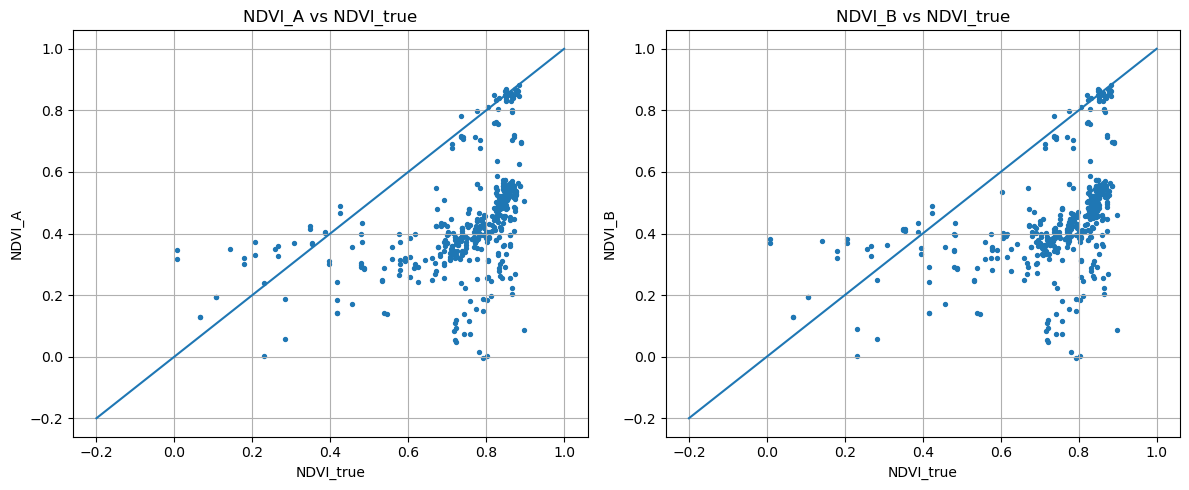

In [64]:
mask_A = df_comp["NDVI_true"].notna() & df_comp["NDVI_A"].notna()
mask_B = df_comp["NDVI_true"].notna() & df_comp["NDVI_B"].notna()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_comp.loc[mask_A, "NDVI_true"], df_comp.loc[mask_A, "NDVI_A"], s=8)
plt.plot([-0.2, 1.0], [-0.2, 1.0])  # 1-1 line
plt.title("NDVI_A vs NDVI_true")
plt.xlabel("NDVI_true")
plt.ylabel("NDVI_A")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(df_comp.loc[mask_B, "NDVI_true"], df_comp.loc[mask_B, "NDVI_B"], s=8)
plt.plot([-0.2, 1.0], [-0.2, 1.0])
plt.title("NDVI_B vs NDVI_true")
plt.xlabel("NDVI_true")
plt.ylabel("NDVI_B")
plt.grid(True)

plt.tight_layout()
plt.show()

We have two clusters:
- low-NDVI cluster around `[0.2, 0.4]`
- high-NDVI cluster around `[0.8, 0.9]`

Both branches hug the low cluster decently. The real issue is the high-NDVI regime.

In the right half of each plot:
- **MODIS** says: strong vegetation `[0.7–0.9]`
- Both **A** and **B** say: meh...`[0.35–0.55]`

This is a systematic underestimation.

Key difference:
- Branch **A** spreads out more vertically, it preserves relative differences in greenness between points
- Branch **B** collapses values into a tight horizontal band, everything looks the same despite **MODIS** varying a lot

So **B** “compresses” the signal...
**A** still underestimates, but tracks variation...

### Smoothness and Temporal Structure

In [65]:
def temporal_variation(series):
    s = series.dropna()
    if len(s) < 2:
        return np.nan
    diffs = np.abs(np.diff(s.values))
    return {
        "mean_step": float(np.mean(diffs)),
        "median_step": float(np.median(diffs)),
        "total_variation": float(np.sum(diffs)),
        "n": len(s),
    }

print("=== Temporal variation for NDVI ===")
print("Branch A:", temporal_variation(df_comp["NDVI_A"]))
print("Branch B:", temporal_variation(df_comp["NDVI_B"]))
print("Truth   :", temporal_variation(df_comp["NDVI_true"]))

=== Temporal variation for NDVI ===
Branch A: {'mean_step': 0.026888691485187143, 'median_step': 0.01078892619878316, 'total_variation': 99.7570454100443, 'n': 3711}
Branch B: {'mean_step': 0.021012017067085425, 'median_step': 0.0073800196468278845, 'total_variation': 77.95458331888693, 'n': 3711}
Truth   : {'mean_step': 0.05306382449044514, 'median_step': 0.0025861759331765044, 'total_variation': 22.9235721798723, 'n': 433}


Variation per day:
- **GT** barely jiggles most days (low median step) but has big seasonal swings (total variation ~23)
- Branch **A** exaggerates short-term wiggles and invents way too much motion (total variation ~100)
- Branch **B** smooths everything too much and wipes out important dynamics (total variation ~78)

So:
- **A** = high-frequency noise injection
- **B** = over-smoothing / signal collapse
- **GT** sits in between...smooth day-to-day, strong seasonal shape

### Correlation With Soil Moisture

In [66]:
if "soil_moisture_5cm" in df_comp.columns:
    sm = df_comp["soil_moisture_5cm"]
    print("=== Correlation with soil_moisture_5cm ===")
    for a, b in feature_pairs:
        corr_A = df_comp[[a, "soil_moisture_5cm"]].dropna().corr().iloc[0, 1]
        corr_B = df_comp[[b, "soil_moisture_5cm"]].dropna().corr().iloc[0, 1]
        print(f"{a} vs {b}: {corr_A:.3f}  |  {corr_B:.3f}")

=== Correlation with soil_moisture_5cm ===
NDVI_A vs NDVI_B: -0.436  |  -0.390
NDMI_A vs NDMI_B: -0.141  |  -0.143
SAR_Ratio_A vs SAR_Ratio_B: -0.519  |  -0.580
SAR_Diff_A vs SAR_Diff_B: -0.365  |  -0.365
Veg_Contrast_A vs Veg_Contrast_B: 0.425  |  0.364


**Correlation with soil moisture**

These correlations test whether the remotely sensed vegetation signal still reflects real ground hydrology

| Feature | Branch A | Branch B | Winner | Reason |
|--------|---------:|---------:|--------|--------|
| NDVI | -0.436 | -0.390 | A | Stronger linkage to soil moisture behavior |
| NDMI | -0.141 | -0.143 | Tie | Layer moisture sensitivity is weak in this site |
| SAR Ratio | -0.519 | -0.580 | B | Stronger dielectric response from radar |
| SAR Diff | -0.365 | -0.365 | Tie | Both capture similar variability |
| Veg Contrast | 0.425 | 0.364 | A | Better vegetation stress response |

**Interpretation**

A higher magnitude means the satellite data is more sensitive to changes in soil moisture. The sign here is negative because vegetation increases as the top soil layer dries out during active plant growth. The key point is how strong that relationship is, not whether it is positive or negative.

Branch A:
* Vegetation indices follow soil moisture more realistically
* Better ecological signal related to actual plant water use

Branch B:
* Radar features show slightly stronger moisture sensitivity
* Vegetation response is overly smooth and sometimes unrealistic

**Takeaways**

If the goal is to support soil moisture estimation and preserve vegetation dynamics:
* Then branch A should be the primary source of vegetation features

If the goal is to stabilize noisy radar measurements:
* Then branch B can assist but should not override Branch A signals!

### Side by Side Time Series

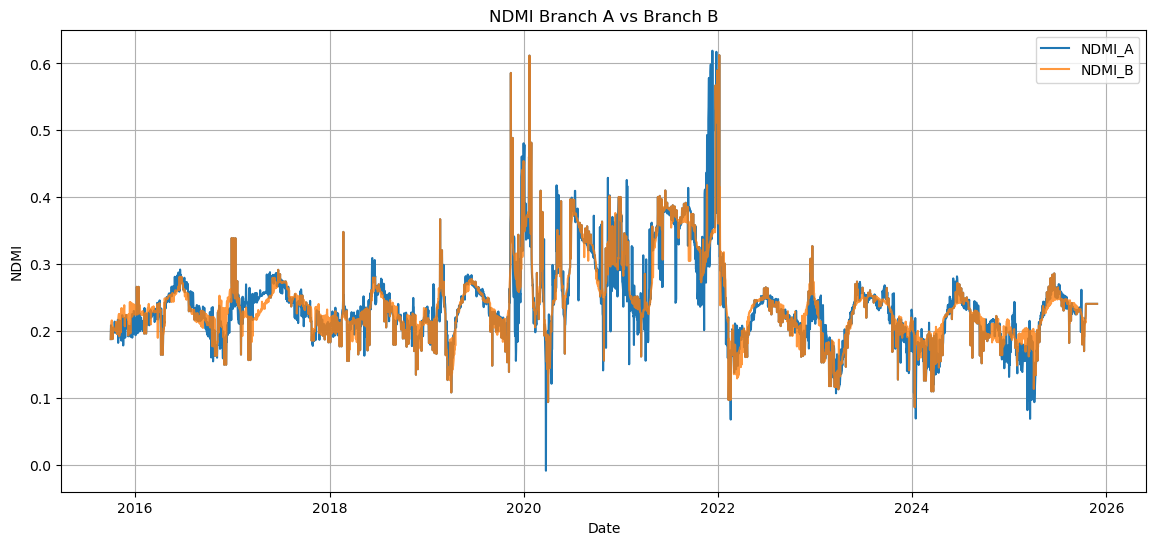

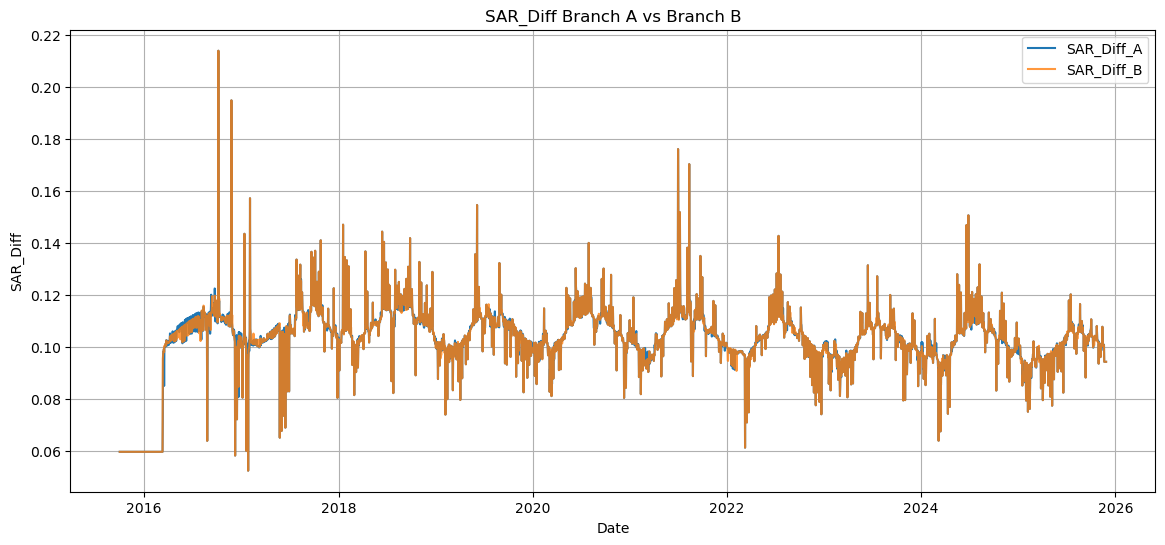

In [67]:
plt.figure(figsize=(14, 6))
plt.plot(df_comp["date"], df_comp["NDMI_A"], label="NDMI_A")
plt.plot(df_comp["date"], df_comp["NDMI_B"], label="NDMI_B", alpha=0.8)
plt.title("NDMI Branch A vs Branch B")
plt.xlabel("Date")
plt.ylabel("NDMI")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(df_comp["date"], df_comp["SAR_Diff_A"], label="SAR_Diff_A")
plt.plot(df_comp["date"], df_comp["SAR_Diff_B"], label="SAR_Diff_B", alpha=0.8)
plt.title("SAR_Diff Branch A vs Branch B")
plt.xlabel("Date")
plt.ylabel("SAR_Diff")
plt.legend()
plt.grid(True)
plt.show()

### Error Distributions (NDVI)

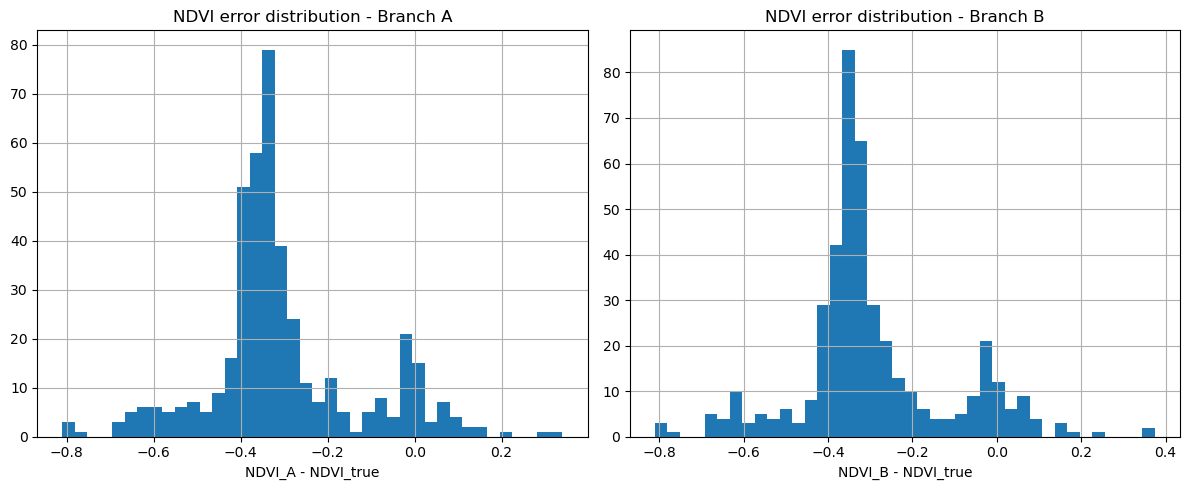

In [ ]:
err_A = (df_comp["NDVI_A"] - df_comp["NDVI_true"]).dropna()
err_B = (df_comp["NDVI_B"] - df_comp["NDVI_true"]).dropna()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(err_A, bins=40)
plt.title("NDVI error distribution - Branch A")
plt.xlabel("NDVI_A - NDVI_true")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(err_B, bins=40)
plt.title("NDVI error distribution - Branch B")
plt.xlabel("NDVI_B - NDVI_true")
plt.grid(True)

plt.tight_layout()
plt.show()

Both branches show a consistent negative bias relative to the MODIS truth. The histograms confirm what we saw earlier in the summary statistics:
- Branch **A** has a slightly tighter central mass but more extreme positive outliers
- Branch **B** has a slightly more compact core and fewer large positive errors

Both approaches systematically underestimate NDVI during strong vegetation periods. That bias is a known consequence of relying on Sentinel reflectance without a full atmospheric correction step. The important part is that neither branch introduces a pathological skew or bimodal error pattern. Their errors are simply shifted lower, and Branch B shifts a bit lower than Branch **A**.

**Bottom line**: Branch **A** and **B** both underestimate peak NDVI, with Branch **B** leaning slightly stronger in that direction. Neither distribution shows strong instability, so the bias can be corrected later if needed.


### Disclaimer

MODIS NDVI is not true ground truth. It is a higher level satellite product that has already been smoothed and interpolated before we ever see it. We use it as a reference for two practical reasons:

1. MODIS vegetation indices are generally considered more stable and accurate than Sentinel derived NDVI for long term land surface monitoring.
2. We need an external benchmark to compare Branch A and Branch B against, and MODIS provides a reasonable reference curve.

Because of this, any agreement with MODIS should be interpreted as alignment with an established satellite product, not as perfect correspondence to real world vegetation. When drawing final conclusions, correlation with actual in situ soil moisture is the more meaningful physical metric.

## Conclusion  

Branch B performs slightly better when scoring directly against the MODIS reference NDVI (lower RMSE and MAE, slightly reduced bias). However, Branch A shows stronger physical relationships to real ground measurements like surface soil moisture and maintains more realistic temporal structure. Given those strengths + my humble opinion, Branch A is the preferable strategy for the operational pipeline, since we ultimately care about physically meaningful variation rather than best matching an already interpolated satellite product.

---
**Jakob Balkovec**